# Customer Segmentation with RFM + K-Means

This notebook walks through the same pipeline as `run_analysis.py`, narrated
step by step. All the actual logic (RFM computation, k-means fitting, k
selection, segment profiling/labeling) lives in the `analysis/` and `data/`
packages — this notebook only imports and calls it, so there is a single
source of truth for the analysis.

We use the real UK Online Retail II transaction dataset (invoice-level
e-commerce data, ~1M rows), fetched via the Kaggle API and cached locally
after first download.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Make the project root (containing analysis/ and data/) importable regardless
# of whether this notebook is executed from notebooks/ or the project root.
for candidate in [Path.cwd(), Path.cwd().parent]:
    if (candidate / "analysis").is_dir() and (candidate / "data").is_dir():
        sys.path.insert(0, str(candidate))
        break

from analysis.clustering import evaluate_k_range, fit_kmeans, scale_features
from analysis.rfm import compute_rfm
from analysis.segment_actions import label_all_clusters, profile_clusters
from data.load_online_retail import load_raw

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load the real transaction data

`load_raw()` loads the cached Online Retail II CSV (invoice-level line
items with customer IDs, product descriptions, quantities, and prices).

In [2]:
raw = load_raw()
print(f"Loaded {len(raw):,} raw transaction rows.")
raw.head()

Loaded 1,067,371 raw transaction rows.


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom


## 2. Compute RFM features

`compute_rfm()` drops rows with no Customer ID, excludes cancelled orders
(Invoice starting with "C") and non-positive quantities, then aggregates
each customer's:

- **Recency** — days since their most recent purchase
- **Frequency** — number of distinct invoices (orders)
- **Monetary** — total amount spent

In [3]:
rfm = compute_rfm(raw)
print(f"Computed RFM for {len(rfm):,} real customers.")
rfm.head()

Computed RFM for 5,881 real customers.


,CustomerID,Recency,Frequency,Monetary
0,"12,346.00",326,12,"77,556.46"
1,"12,347.00",2,8,"5,633.32"
2,"12,348.00",75,5,"2,019.40"
3,"12,349.00",19,4,"4,428.69"
4,"12,350.00",310,1,334.40


## 3. Select k via elbow + silhouette score

`evaluate_k_range()` fits k-means for each k in the given range on the
standardized RFM features and reports inertia (for the elbow heuristic) and
the silhouette score. We pick the k with the highest silhouette score.

In [4]:
k_scores = evaluate_k_range(rfm, range(2, 9))
k_scores

,k,inertia,silhouette
0,2,"8,904.86",0.42
1,3,"5,743.52",0.40
2,4,"4,500.02",0.36
3,5,"3,651.01",0.37
4,6,"3,091.58",0.35
5,7,"2,751.09",0.34
6,8,"2,485.07",0.32


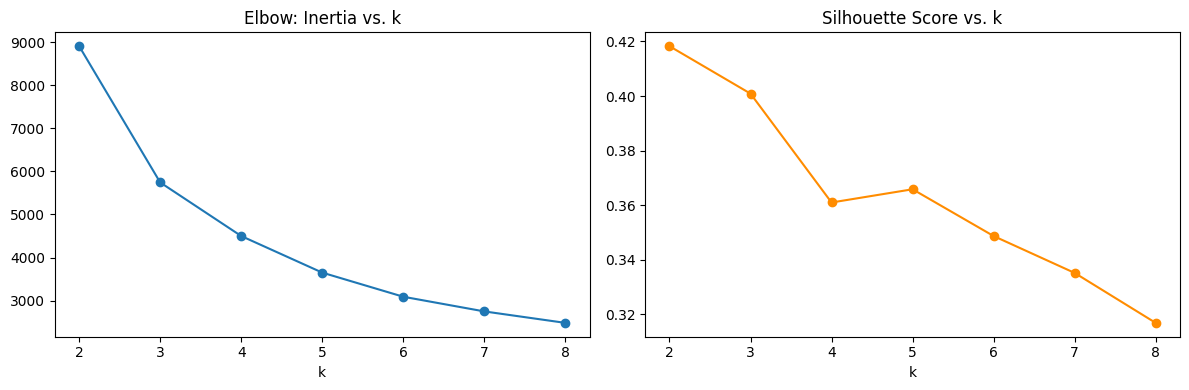

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_scores["k"], k_scores["inertia"], marker="o")
ax[0].set_title("Elbow: Inertia vs. k")
ax[0].set_xlabel("k")
ax[1].plot(k_scores["k"], k_scores["silhouette"], marker="o", color="darkorange")
ax[1].set_title("Silhouette Score vs. k")
ax[1].set_xlabel("k")
fig.tight_layout()
plt.show()

In [6]:
best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"])
print(f"Selected k={best_k} (highest silhouette score).")

Selected k=2 (highest silhouette score).


## 4. Fit the final k-means model

Refit k-means at the chosen `best_k` and attach the cluster label back onto
each customer's RFM row.

In [7]:
model, labels = fit_kmeans(rfm, k=best_k)
rfm_clustered = rfm.copy()
rfm_clustered["Cluster"] = labels
rfm_clustered.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,"12,346.00",326,12,"77,556.46",0
1,"12,347.00",2,8,"5,633.32",0
2,"12,348.00",75,5,"2,019.40",0
3,"12,349.00",19,4,"4,428.69",0
4,"12,350.00",310,1,334.40,1


## 5. Visualize the segments with PCA

Project the standardized RFM features down to 2 dimensions with PCA so the
clusters can be visualized on a scatter plot.

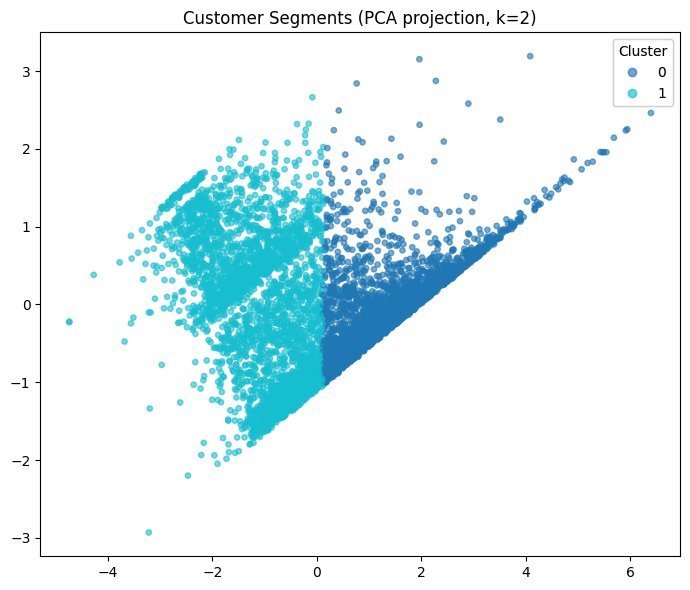

In [8]:
X_scaled = scale_features(rfm_clustered)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

fig2, ax2 = plt.subplots(figsize=(7, 6))
scatter = ax2.scatter(coords[:, 0], coords[:, 1], c=rfm_clustered["Cluster"], cmap="tab10", alpha=0.6, s=15)
ax2.set_title(f"Customer Segments (PCA projection, k={best_k})")
legend = ax2.legend(*scatter.legend_elements(), title="Cluster")
ax2.add_artist(legend)
fig2.tight_layout()
plt.show()

## 6. Profile and label each cluster

`profile_clusters()` summarizes each cluster's size, share of customers,
share of total revenue, and average Recency/Frequency/Monetary.
`label_all_clusters()` then maps each cluster to a named segment (e.g.
Champions, Loyal Customers, At Risk, Hibernating) and a concrete marketing
action, based on how that cluster's RFM averages compare to the **real
customer base's median Recency/Frequency/Monetary** (computed across all
individual customers below, before/regardless of clustering — not a median
of the per-cluster averages).

In [9]:
# Real median Recency/Frequency/Monetary across all individual customers
# (before/regardless of clustering) — the baseline label_all_clusters
# benchmarks each cluster against.
overall_medians = rfm_clustered[["Recency", "Frequency", "Monetary"]].median()

profile = profile_clusters(rfm_clustered)
profile = label_all_clusters(profile, overall_medians)
profile

,Cluster,CustomerCount,PctCustomers,PctRevenue,Recency,Frequency,Monetary,Segment,MarketingAction
0,0,2678,45.54,90.25,63.14,11.59,"5,979.58",Champions,Enroll in a loyalty/VIP rewards program to pro...
1,1,3203,54.46,9.75,317.11,1.85,540.15,Hibernating,Low-cost re-engage email; deprioritize spend v...


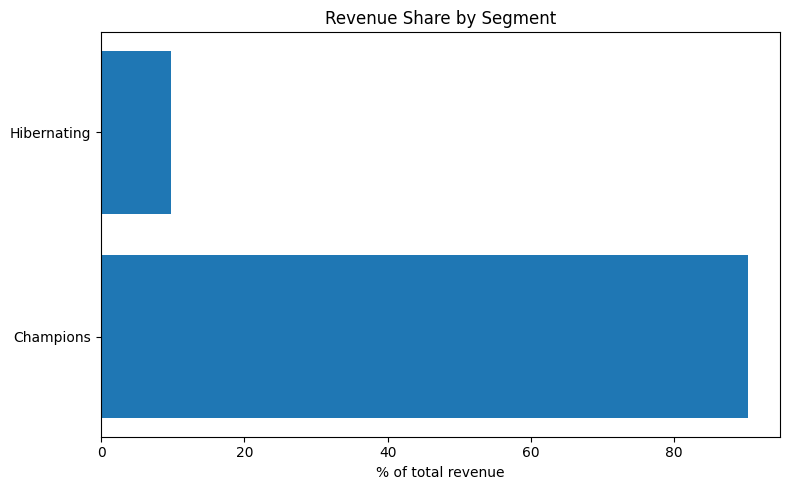

In [10]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
ax3.barh(profile["Segment"], profile["PctRevenue"])
ax3.set_xlabel("% of total revenue")
ax3.set_title("Revenue Share by Segment")
fig3.tight_layout()
plt.show()

## 7. Marketing actions per segment

The table above pairs each real, data-derived segment with a concrete
recommended action:

- **Champions** — recent, frequent, high-spend customers. Enroll them in a
  loyalty/VIP rewards program to protect this high-value relationship.
- **Loyal Customers** — buy recently and often. Run upsell/cross-sell
  campaigns to grow their basket size.
- **New / Promising** — recent but not yet frequent. Put them in an
  onboarding nurture campaign to convert a first purchase into a habit.
- **At Risk** — used to be frequent or high-value but haven't purchased
  recently. Send a targeted win-back offer before they churn.
- **Hibernating** — not recent, not frequent, low spend. Use a low-cost
  re-engagement email and deprioritize spend relative to other segments —
  further investment here has the weakest expected return.

With Frequency and Monetary log-transformed before scaling (standard
practice for the heavily right-skewed spend/order-count distributions real
retail data has), this run's real k-means result lands on k=2 with a
genuinely balanced, behaviorally distinct split: **Champions** are 45.5% of
customers (2,678 people) averaging 63 days since last purchase, ~11.6
orders, and ~$5,980 spent — they drive 90.2% of total revenue. **Hibernating**
is the other 54.5% (3,203 people), averaging 317 days since last purchase,
~1.9 orders, and ~$540 spent, contributing only 9.8% of revenue. The
practical takeaway: engaged, recent, frequent buyers make up nearly half the
customer base and should be the loyalty-program priority, while the lapsed
half warrants only low-cost re-engagement — a much more actionable split
than an outlier-driven "whales vs. everyone" segmentation would have given.